In [1]:
#@title install
%pip install -q --break-system-packages yfinance xgboost scikit-learn matplotlib pandas plotly nbformat
%pip install -q --break-system-packages ta

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# XGBoost

## Contexto del Notebook
Este notebook documenta un flujo completo de modelado para prediccion direccional en mercados financieros.

El objetivo es predecir si el precio de cierre futuro sera mayor o menor que el actual para distintos horizontes de tiempo.

Herramientas principales usadas en el flujo:
- yfinance para descargar datos historicos.
- ta para indicadores tecnicos.
- XGBoost para clasificacion supervisada.
- scikit-learn para particion, metricas y validacion.
- matplotlib/plotly para visualizacion de resultados.

In [2]:
#@title import
import ta
import yfinance as yf
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


from itertools import combinations
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid

I0000 00:00:1774483975.768602   23600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774483975.769477   23600 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774483975.893429   23600 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774483979.715756   23600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

### 1 dia

### Que se hace en esta seccion (1 dia)
1. Se construyen features tecnicos sobre EURUSD.
2. Se ejecuta una busqueda de hiperparametros con separacion temporal train/valid/test.
3. Se selecciona la mejor configuracion por validacion (no por test).
4. Se reentrena un modelo final y se evalua en bloque holdout.

Nota: el test se usa solo para medir generalizacion final.

In [3]:
#@title Entrenamiento modelo prediccion a 1 dia (tuning rapido sin fuga de test)
# Datos
symbol = 'EURUSD=X'
data = yf.download(symbol, start="2002-01-01", end="2025-08-01", interval='1d')

# Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Target: 1 si sube 0 si baja
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Features base
data['Return_1d'] = data['Close'].pct_change()
data['Return_5d'] = data['Close'].pct_change(periods=5)
data['Return_10d'] = data['Close'].pct_change(periods=10)
data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
if 'Volume' in data.columns:
    data.drop(columns=['Volume'], inplace=True)

# Funcion para generar features dinamicamente
def generate_features(data, rsi_window, willr_window, bb_window, alpha, selected_features):
    df = data.copy()

    df['RSI'] = ta.momentum.RSIIndicator(close=df['Close'], window=rsi_window).rsi()
    df['WILLR'] = ta.momentum.WilliamsRIndicator(
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
        lbp=willr_window
    ).williams_r()

    bb = ta.volatility.BollingerBands(close=df['Close'], window=bb_window, window_dev=2)
    df['BB_percent_B'] = bb.bollinger_pband()

    change = abs(df['Return_1d'])
    df['Weight'] = 1 / (1 + alpha * change)

    df.dropna(inplace=True)

    X = df[selected_features]
    y = df['Target']
    w = df['Weight']

    return X, y, w

# Parametros a probar
param_grid = {
    'alpha': range(0, 1000, 5),
    'rsi_window': [2, 5],
    'willr_window': [7],
    'bb_window': [5, 7],
    'features_subset': [
        ['Return_1d', 'Return_5d', 'Return_10d', 'RSI', 'WILLR', 'MA_5', 'MA_10', 'BB_percent_B'],
    ]
}

def temporal_split(X, y, w, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    return (
        X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:],
        y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:],
        w.iloc[:train_end], w.iloc[train_end:val_end], w.iloc[val_end:],
    )

# Muestreo aleatorio para acelerar la busqueda
all_params = list(ParameterGrid(param_grid))
max_trials = 80
rng = np.random.default_rng(42)
n_trials = min(max_trials, len(all_params))
sampled_idx = rng.choice(len(all_params), size=n_trials, replace=False)
sampled_params = [all_params[i] for i in sampled_idx]

print(f'Probando {n_trials} combinaciones de {len(all_params)} posibles...')

results = []
for params in sampled_params:
    X, y, w = generate_features(
        data,
        rsi_window=params['rsi_window'],
        willr_window=params['willr_window'],
        bb_window=params['bb_window'],
        alpha=params['alpha'],
        selected_features=params['features_subset']
    )

    if len(X) < 300:
        continue

    (
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        w_train, w_val, w_test,
    ) = temporal_split(X, y, w)

    if len(X_val) == 0 or len(X_test) == 0:
        continue

    model = XGBClassifier(eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train, sample_weight=w_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append({
        'params': params,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'n_obs': len(X),
    })

# Ordenar por validacion para evitar fuga de test
results_df = pd.DataFrame(results).sort_values(by='val_accuracy', ascending=False)
print(results_df[['val_accuracy', 'test_accuracy', 'params']].head(10))

if not results_df.empty:
    best_params = results_df.iloc[0]['params']
    print('Mejores parametros por validacion:', best_params)
else:
    best_params = None
    print('No hubo resultados validos en la malla.')

[*********************100%***********************]  1 of 1 completed


Probando 80 combinaciones de 800 posibles...
    val_accuracy  test_accuracy  \
30      0.602496       0.578807   
6       0.598930       0.585040   
34      0.597148       0.604630   
28      0.595365       0.601959   
65      0.591800       0.592164   
18      0.591800       0.594835   
61      0.590018       0.577916   
44      0.590018       0.591273   
9       0.589127       0.596616   
64      0.588235       0.591273   

                                               params  
30  {'alpha': 560, 'bb_window': 7, 'features_subse...  
6   {'alpha': 720, 'bb_window': 7, 'features_subse...  
34  {'alpha': 415, 'bb_window': 5, 'features_subse...  
28  {'alpha': 415, 'bb_window': 5, 'features_subse...  
65  {'alpha': 785, 'bb_window': 5, 'features_subse...  
18  {'alpha': 155, 'bb_window': 5, 'features_subse...  
61  {'alpha': 945, 'bb_window': 7, 'features_subse...  
44  {'alpha': 890, 'bb_window': 5, 'features_subse...  
9   {'alpha': 900, 'bb_window': 5, 'features_subse...  
64  {'alp

In [4]:
if 'results_df' in globals() and not results_df.empty:
    results_df = results_df.sort_values(by='val_accuracy', ascending=False)
    results_df.head(10)
else:
    print('results_df esta vacio. Ejecuta primero la celda de tuning.')

In [5]:
(results_df['params'].iloc[0]['features_subset'])

['Return_1d',
 'Return_5d',
 'Return_10d',
 'RSI',
 'WILLR',
 'MA_5',
 'MA_10',
 'BB_percent_B']

In [6]:
results_df['params'].iloc[0]

#obtener el bb_window
(results_df['params'].iloc[0]['bb_window'],
 results_df['params'].iloc[1]['bb_window'],
 results_df['params'].iloc[2]['bb_window'],
 results_df['params'].iloc[3]['bb_window'],
 results_df['params'].iloc[4]['bb_window'],
 results_df['params'].iloc[5]['bb_window'])

(7, 7, 5, 5, 5, 5)

In [7]:
(results_df['params'].iloc[0]['rsi_window'],
 results_df['params'].iloc[1]['rsi_window'],
 results_df['params'].iloc[2]['rsi_window'],
 results_df['params'].iloc[3]['rsi_window'],
 results_df['params'].iloc[4]['rsi_window'],
 results_df['params'].iloc[5]['rsi_window'])

(5, 5, 5, 2, 5, 5)

In [8]:
(results_df['params'].iloc[0]['willr_window'],
 results_df['params'].iloc[1]['willr_window'],
 results_df['params'].iloc[2]['willr_window'],
 results_df['params'].iloc[3]['willr_window'],
 results_df['params'].iloc[4]['willr_window'],
 results_df['params'].iloc[5]['willr_window'])

(7, 7, 7, 7, 7, 7)

## Con el resultado obtenido por la malla

### Reentrenamiento con mejores parametros
En este bloque se toma la mejor configuracion encontrada en la malla y se entrena un modelo final.

Puntos importantes:
- Se mantiene la misma ingenieria de variables entre entrenamiento e inferencia.
- Se guarda una configuracion (`model_config`) para reutilizar ventanas y features de forma consistente.
- Las metricas de salida permiten comparar estabilidad entre corridas.

In [9]:
symbol = 'EURUSD=X'
data = yf.download(symbol, start="2002-01-01", end="2025-08-20", interval='1d')

# Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Target: 1 si sube 0 si baja
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Features base
data['Return_1d'] = data['Close'].pct_change()
data['Return_5d'] = data['Close'].pct_change(periods=5)
data['Return_10d'] = data['Close'].pct_change(periods=10)
data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
if 'Volume' in data.columns:
    data.drop(columns=['Volume'], inplace=True)

# Definir aqui para que la celda sea autosuficiente
def generate_features(data, rsi_window, willr_window, bb_window, alpha, selected_features):
    df = data.copy()
    df['RSI'] = ta.momentum.RSIIndicator(close=df['Close'], window=rsi_window).rsi()
    df['WILLR'] = ta.momentum.WilliamsRIndicator(
        high=df['High'], low=df['Low'], close=df['Close'], lbp=willr_window
    ).williams_r()
    bb = ta.volatility.BollingerBands(close=df['Close'], window=bb_window, window_dev=2)
    df['BB_percent_B'] = bb.bollinger_pband()
    change = abs(df['Return_1d'])
    df['Weight'] = 1 / (1 + alpha * change)
    df.dropna(inplace=True)
    X = df[selected_features]
    y = df['Target']
    w = df['Weight']
    return X, y, w

default_model_config = {
    'rsi_window': 2,
    'willr_window': 7,
    'bb_window': 5,
    'alpha': 345,
    'features_subset': [
        'Return_1d', 'Return_5d', 'Return_10d', 'RSI',
        'WILLR', 'MA_5', 'MA_10', 'BB_percent_B'
    ]
}

# Usar mejores parametros de la malla por validacion si existen
if 'results_df' in globals() and not results_df.empty:
    model_config = results_df.iloc[0]['params']
else:
    model_config = default_model_config

features = model_config['features_subset']

X, y, w = generate_features(
    data,
    rsi_window=model_config['rsi_window'],
    willr_window=model_config['willr_window'],
    bb_window=model_config['bb_window'],
    alpha=model_config['alpha'],
    selected_features=features,
 )

# Split temporal para evaluacion final
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, shuffle=False, random_state=42
)

# Entrenar modelo final
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train, sample_weight=w_train)

# Prediccion
y_pred = model.predict(X_test)

print('Configuracion usada:', model_config)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[*********************100%***********************]  1 of 1 completed


Configuracion usada: {'alpha': 560, 'bb_window': 7, 'features_subset': ['Return_1d', 'Return_5d', 'Return_10d', 'RSI', 'WILLR', 'MA_5', 'MA_10', 'BB_percent_B'], 'rsi_window': 5, 'willr_window': 7}
Accuracy: 0.6222222222222222
              precision    recall  f1-score   support

           0       0.66      0.56      0.61       587
           1       0.59      0.69      0.64       538

    accuracy                           0.62      1125
   macro avg       0.63      0.63      0.62      1125
weighted avg       0.63      0.62      0.62      1125



In [10]:
#@title Predicción a 1 dia para USDCOP usando el modelo entrenado en EURUSD
#Datos
symbol = 'COPUSD=X' # Using COPUSD=X as per the other USDCOP cell
data = yf.download(symbol, start="2010-01-01", end="2024-12-31", interval='1d')

#Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


#Target: 1 si sube 0 si baja
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Features - Using the same features as the EURUSD 1-day model
data['Return_1d'] = data['Close'].pct_change()
data['Return_5d'] = data['Close'].pct_change(periods=5)
data['Return_10d'] = data['Close'].pct_change(periods=10)
data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
data.drop(columns=['Volume'], inplace=True)

# Recalculate technical indicators for the new data using the best parameters from the EURUSD 1-day grid search
# The best parameters for EURUSD 1-day were alpha=0, bb_window=7, rsi_window=2, willr_window=7
# However, the features list used in the EURUSD 1-day re-training cell was ['Return_1d', 'Return_5d', 'Return_10d', 'RSI', 'WILLR', 'MA_5', 'MA_10', 'BB_percent_B']
# And the parameters used in that cell were rsi_window=2, willr_window=7, bb_window=5, alpha=345
# I will use the features and parameters from the re-training cell for consistency
features =  [
  'Return_1d',
  'Return_5d',
  'Return_10d',
  'RSI',
  'WILLR',
  'MA_5',
  'MA_10',
  'BB_percent_B']

# Recalculate technical indicators with the specific windows
data['RSI'] = ta.momentum.RSIIndicator(close=data['Close'], window=2).rsi()
data['WILLR'] = ta.momentum.WilliamsRIndicator(high=data['High'], low=data['Low'], close=data['Close'], lbp=7).williams_r()
bb = ta.volatility.BollingerBands(close=data['Close'], window=5, window_dev=2)
data['BB_percent_B'] = bb.bollinger_pband()

# Drop NaN after calculating features
data.dropna(inplace=True)

# Features and target
X = data[features]
y = data['Target']

# Since we are testing on a new symbol, we need to split the data
# Using the same split ratio as in the EURUSD 1-day model
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Predicción usando el modelo entrenado en EURUSD
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[*********************100%***********************]  1 of 1 completed

Accuracy: 0.5891472868217055
              precision    recall  f1-score   support

           0       0.60      0.42      0.49       370
           1       0.58      0.75      0.66       404

    accuracy                           0.59       774
   macro avg       0.59      0.58      0.57       774
weighted avg       0.59      0.59      0.58       774



### Transferencia de modelo: EURUSD -> COPUSD
Aqui se evalua un escenario de transferencia: el modelo entrenado en EURUSD se prueba en COPUSD.

Este experimento mide robustez fuera del dominio de entrenamiento y ayuda a estimar que tan portable es la senal.

In [11]:
data.head()

Price,Close,High,Low,Open,Target,Return_1d,Return_5d,Return_10d,MA_5,MA_10,RSI,WILLR,BB_percent_B
Date,,,,,,,,,,,,,
2010-01-18,0.000517,0.000517,0.000517,0.000517,0,0.001759,-0.001552,0.045257,0.000517,0.000515,64.207386,-56.666982,0.477375
2010-01-19,0.000517,0.000517,0.000517,0.000517,1,-0.001343,-0.003306,0.026343,0.000517,0.000516,39.015628,-79.228661,0.394525
2010-01-20,0.000521,0.000521,0.000521,0.000521,0,0.009069,0.004326,0.027051,0.000517,0.000518,90.307261,-0.000000,0.987455
2010-01-21,0.000521,0.000521,0.000521,0.000521,0,-0.000989,0.009321,0.008487,0.000518,0.000518,76.198016,-9.685566,0.771738
2010-01-22,0.000515,0.000522,0.000515,0.000522,0,-0.010816,-0.002421,-0.002369,0.000518,0.000518,17.267424,-100.000000,0.179563


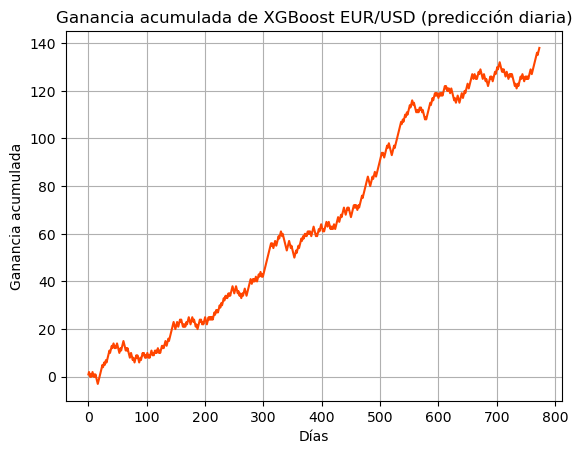

In [12]:
#@title Ganancia acumulada: Gana +1 si acerta, -1 si falla
sim_returns = np.where(y_pred == y_test.values, 1, -1)
cumulative_return = np.cumsum(sim_returns)

plt.plot(cumulative_return,color='orangered')
plt.title("Ganancia acumulada de XGBoost EUR/USD (predicción diaria)")
plt.xlabel("Días")
plt.ylabel("Ganancia acumulada")
plt.grid()
#guardar figura en docs/figures/ganancia_acumulada_xgboost_eurusd_diaria.png
plt.savefig('../docs/figures/ganancia_acumulada_xgboost_eurusd_diaria.png', dpi=300, bbox_inches='tight')
plt.show()

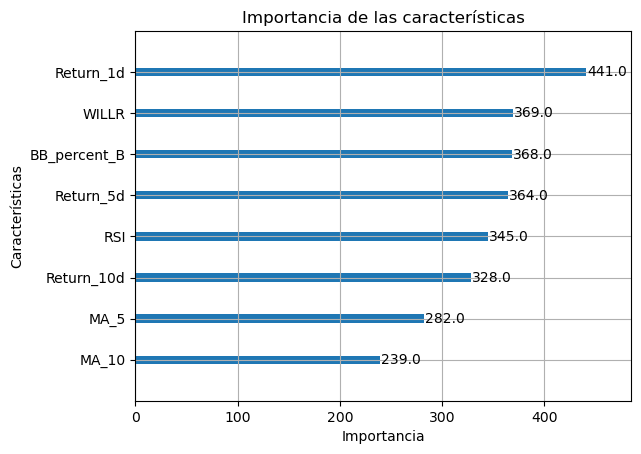

In [13]:
plot_importance(model)
plt.title("Importancia de las características")
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.show()

In [14]:
data_test = data.iloc[-len(y_test):].copy()
data_test['Pred'] = y_pred
#@title Grafica
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data_test.index,
    y=data_test['Close'],
    mode='lines',
    name='Precio EUR/USD',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=data_test.index[data_test['Pred'] == 1],
    y=data_test['Close'][data_test['Pred'] == 1],
    mode='markers',
    name='Predicción: Sube',
    marker=dict(color='green', symbol='triangle-up', size=10)
))

fig.add_trace(go.Scatter(
    x=data_test.index[data_test['Pred'] == 0],
    y=data_test['Close'][data_test['Pred'] == 0],
    mode='markers',
    name='Predicción: Baja',
    marker=dict(color='red', symbol='triangle-down', size=10)
))

fig.update_layout(
    title='EUR/USD y Predicciones de XGBoost',
    xaxis_title='Fecha',
    yaxis_title='Precio de cierre',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

[*********************100%***********************]  1 of 1 completed


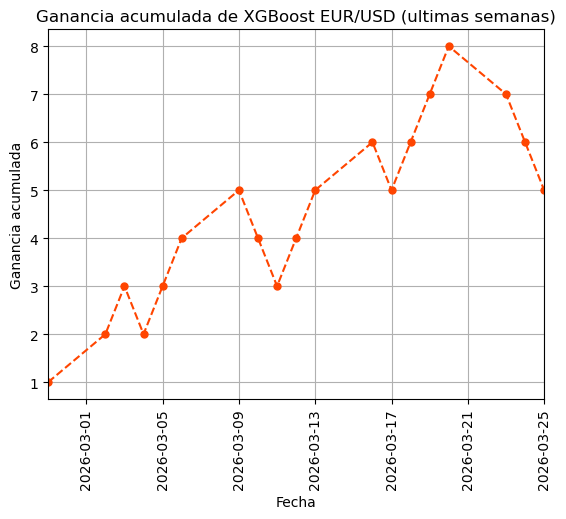

In [15]:
#@title Rendimiento esta semana (consistente con entrenamiento)
symbol_week = 'EURUSD=X'
latest_data = yf.download(symbol_week, period='30d', interval='1d')

if isinstance(latest_data.columns, pd.MultiIndex):
    latest_data.columns = latest_data.columns.get_level_values(0)

# Configuracion por defecto si no existe model_config
default_model_config = {
    'rsi_window': 2,
    'willr_window': 7,
    'bb_window': 5,
    'features_subset': [
        'Return_1d', 'Return_5d', 'Return_10d', 'RSI',
        'WILLR', 'MA_5', 'MA_10', 'BB_percent_B'
    ]
}

cfg = model_config if 'model_config' in globals() else default_model_config
features = cfg['features_subset']

# Mismos features que en entrenamiento
latest_data['Return_1d'] = latest_data['Close'].pct_change()
latest_data['Return_5d'] = latest_data['Close'].pct_change(periods=5)
latest_data['Return_10d'] = latest_data['Close'].pct_change(periods=10)
latest_data['MA_5'] = latest_data['Close'].rolling(5).mean()
latest_data['MA_10'] = latest_data['Close'].rolling(10).mean()

latest_data['RSI'] = ta.momentum.RSIIndicator(
    close=latest_data['Close'], window=cfg['rsi_window']
 ).rsi()
latest_data['WILLR'] = ta.momentum.WilliamsRIndicator(
    high=latest_data['High'], low=latest_data['Low'], close=latest_data['Close'], lbp=cfg['willr_window']
).williams_r()
bb = ta.volatility.BollingerBands(
    close=latest_data['Close'], window=cfg['bb_window'], window_dev=2
)
latest_data['BB_percent_B'] = bb.bollinger_pband()

latest_data = latest_data[features].dropna()

if not latest_data.empty:
    latest_pred = model.predict(latest_data)

    latest_data['Actual_Return'] = latest_data['Return_1d'].shift(-1)
    latest_data['Predicted_Direction'] = latest_pred

    sim_returns_week = []
    for i in range(len(latest_data) - 1):
        if latest_data['Predicted_Direction'].iloc[i] == 1:
            sim_returns_week.append(1 if latest_data['Actual_Return'].iloc[i] > 0 else -1)
        else:
            sim_returns_week.append(1 if latest_data['Actual_Return'].iloc[i] < 0 else -1)

    cumulative_return_week = np.cumsum(sim_returns_week)
    date_index_for_plot = latest_data.index[:len(cumulative_return_week)]

    if len(date_index_for_plot) > 1:
        plt.xlim(date_index_for_plot[0], date_index_for_plot[-1])

    plt.plot(date_index_for_plot, cumulative_return_week, '--', color='orangered', marker='.', markersize=10)
    plt.xticks(rotation=90)
    plt.title('Ganancia acumulada de XGBoost EUR/USD (ultimas semanas)')
    plt.xlabel('Fecha')
    plt.ylabel('Ganancia acumulada')
    plt.grid()
    plt.show()
else:
    print('Not enough data in the last 30 days to generate features.')

Otros features

### Validacion estadistica del resultado
En esta seccion se contrasta el desempeno del modelo contra un baseline aleatorio (moneda justa).

Se usa prueba binomial para responder si la tasa de aciertos observada es significativamente mayor que 0.5.

### Prueba de hipotesis
Variable tipo Bernoulli

Hipótesis nula $H_0$: El modelo acierta igual que el azar → $p=0.5$

Hipótesis alternativa $H_A$: El modelo acierta más que el azar $p>5$



Se hace un Z test
$Z = \frac{\hat{p}-p}{Var(\hat{p})}$

Donde $Var(\hat{p}) = \frac{p(1-p)}{n}$

Y bajo la hipotesis nula:
$Var(\hat{p}) = \frac{p_0(1-p_0)}{n}$

In [16]:
from scipy.stats import binomtest

def test_vs_coinflip(accuracy, n, alpha=0.05):
    """
    Prueba de hipótesis: comparar accuracy de un modelo contra un coinflip (p=0.5)

    Parámetros:
        accuracy (float): exactitud del modelo (entre 0 y 1)
        n (int): número de predicciones
        alpha (float): nivel de significancia, por defecto 0.05

    Retorna:
        dict con resultados de la prueba
    """
    # número de aciertos del modelo
    k = int(round(accuracy * n))

    # prueba binomial
    test = binomtest(k, n, p=0.5, alternative="greater")

    return {
        "aciertos": k,
        "total": n,
        "accuracy": accuracy,
        "p_value": float(test.pvalue),
        "rechaza_H0": test.pvalue < alpha
    }


In [17]:
print(f"{test_vs_coinflip(0.60, 8791)['p_value']:.3e}")

2.946e-79


In [18]:
acc = accuracy_score(y_test, y_pred)
test_vs_coinflip(acc, len(y_test))


{'aciertos': 456,
 'total': 774,
 'accuracy': 0.5891472868217055,
 'p_value': 3.970099913379054e-07,
 'rechaza_H0': True}

In [19]:
print(f"{test_vs_coinflip(acc, len(y_test))['p_value']:.3e}")

3.970e-07


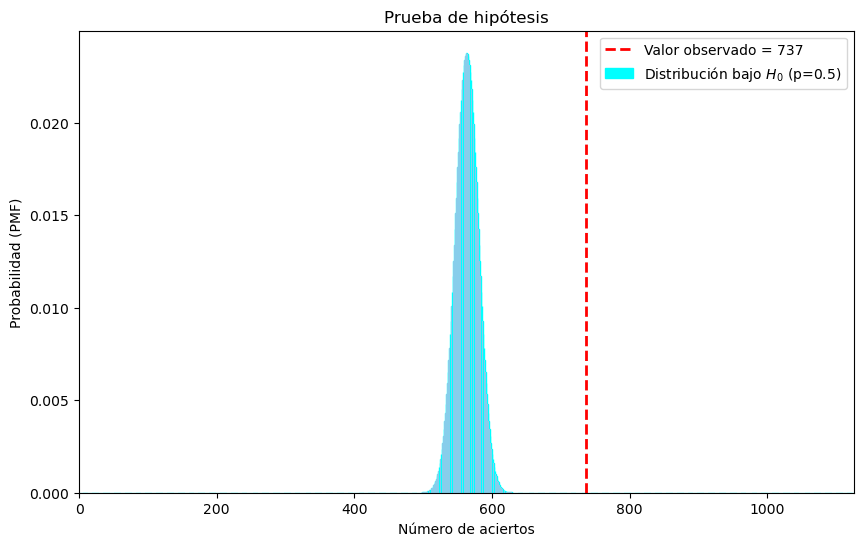

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Datos del usuario
aciertos = 737
total = 1126
p0 = 0.5  # hipótesis nula: como lanzar una moneda

# Calcular distribución binomial bajo H0
x = np.arange(0, total+1)
pmf = binom.pmf(x, total, p0)

# Graficar
plt.figure(figsize=(10,6))
plt.bar(x, pmf, color="cyan", edgecolor="cyan", alpha=1, label="Distribución bajo $H_0$ (p=0.5)")


# Resaltar el valor observado
plt.axvline(aciertos, color="red", linestyle="--", linewidth=2, label=f"Valor observado = {aciertos}")

# Rellenar las colas (rechazo H0)
cola_izq = x <= aciertos
cola_der = x >= aciertos
plt.bar(x[cola_izq], pmf[cola_izq], color="skyblue")
plt.bar(x[cola_der], pmf[cola_der], color="skyblue")

plt.title("Prueba de hipótesis")
plt.xlabel("Número de aciertos")
plt.ylabel("Probabilidad (PMF)")
plt.xlim(0, total)
plt.legend()
plt.show()

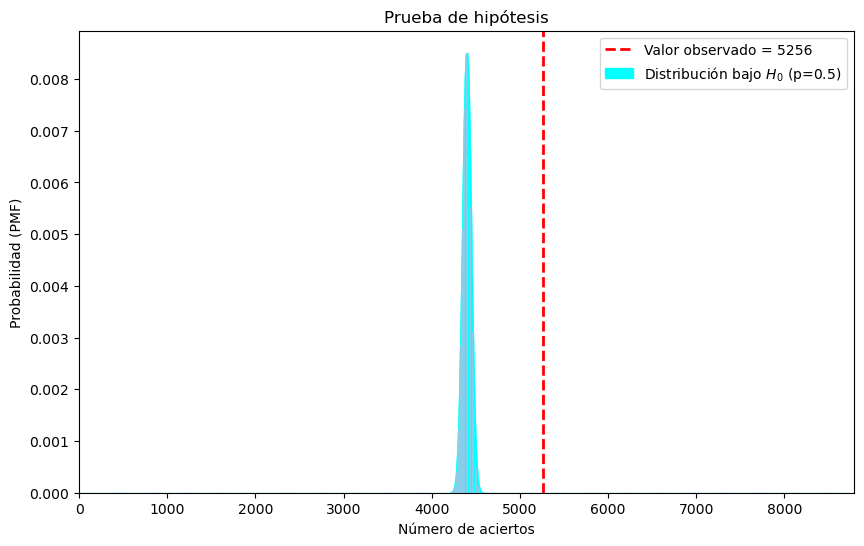

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Datos del usuario
aciertos = 5256
total = 8791
p0 = 0.5  # hipótesis nula: como lanzar una moneda

# Calcular distribución binomial bajo H0
x = np.arange(0, total+1)
pmf = binom.pmf(x, total, p0)

# Graficar
plt.figure(figsize=(10,6))
plt.bar(x, pmf, color="cyan", edgecolor="cyan", alpha=1, label="Distribución bajo $H_0$ (p=0.5)")


# Resaltar el valor observado
plt.axvline(aciertos, color="red", linestyle="--", linewidth=2, label=f"Valor observado = {aciertos}")

# Rellenar las colas (rechazo H0)
cola_izq = x <= aciertos
cola_der = x >= aciertos
plt.bar(x[cola_izq], pmf[cola_izq], color="skyblue")
plt.bar(x[cola_der], pmf[cola_der], color="skyblue")

plt.title("Prueba de hipótesis")
plt.xlabel("Número de aciertos")
plt.ylabel("Probabilidad (PMF)")
plt.xlim(0, total)
plt.legend()
plt.show()

##NASDAQ o US100

### Experimentos en NASDAQ (US100 proxy)
Este bloque replica la logica de features y entrenamiento sobre un activo de renta variable.

Sirve para evaluar si la metodologia se comporta de forma similar en un mercado diferente a FX.

In [23]:
#@title Entrenamiento NASDAQ 1 dia (tuning temporal sin fuga de test)
# Datos
symbol = "^IXIC"
data = yf.download(symbol, start="2010-01-01", end="2025-12-31", interval='1d')

# Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Target: 1 si sube 0 si baja
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Features base
data['Return_1d'] = data['Close'].pct_change()
data['Return_5d'] = data['Close'].pct_change(periods=5)
data['Return_7d'] = data['Close'].pct_change(periods=7)
data['Return_10d'] = data['Close'].pct_change(periods=10)
data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
if 'Volume' in data.columns:
    data.drop(columns=['Volume'], inplace=True)

# Funcion para generar features dinamicamente
def generate_features_nasdaq(data, rsi_window, willr_window, bb_window, alpha, selected_features):
    df = data.copy()
    df['RSI'] = ta.momentum.RSIIndicator(close=df['Close'], window=rsi_window).rsi()
    df['WILLR'] = ta.momentum.WilliamsRIndicator(
        high=df['High'], low=df['Low'], close=df['Close'], lbp=willr_window
    ).williams_r()
    bb = ta.volatility.BollingerBands(close=df['Close'], window=bb_window, window_dev=2)
    df['BB_percent_B'] = bb.bollinger_pband()

    change = abs(df['Return_1d'])
    df['Weight'] = 1 / (1 + alpha * change)
    df.dropna(inplace=True)

    X = df[selected_features]
    y = df['Target']
    w = df['Weight']
    return X, y, w

def temporal_split(X, y, w, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return (
        X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:],
        y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:],
        w.iloc[:train_end], w.iloc[train_end:val_end], w.iloc[val_end:],
    )

# Parametros a probar (mismo estilo de tuning rapido)
param_grid = {
    'alpha': range(0, 600, 10),
    'rsi_window': [7, 14, 21],
    'willr_window': [7, 14],
    'bb_window': [5, 10, 15],
    'features_subset': [
        ['Return_1d', 'Return_5d', 'Return_10d', 'RSI', 'WILLR', 'BB_percent_B'],
        ['Return_1d', 'Return_5d', 'Return_10d', 'RSI', 'WILLR', 'MA_5', 'MA_10', 'BB_percent_B'],
        ['Return_1d', 'Return_5d', 'Return_7d', 'Return_10d', 'RSI', 'WILLR', 'MA_5', 'MA_10', 'BB_percent_B']
    ]
}

all_params = list(ParameterGrid(param_grid))
max_trials = 60
rng = np.random.default_rng(42)
n_trials = min(max_trials, len(all_params))
sampled_idx = rng.choice(len(all_params), size=n_trials, replace=False)
sampled_params = [all_params[i] for i in sampled_idx]

print(f'Probando {n_trials} combinaciones de {len(all_params)} posibles...')

results_nasdaq = []
for params in sampled_params:
    X, y, w = generate_features_nasdaq(
        data,
        rsi_window=params['rsi_window'],
        willr_window=params['willr_window'],
        bb_window=params['bb_window'],
        alpha=params['alpha'],
        selected_features=params['features_subset']
    )

    if len(X) < 300:
        continue

    (
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        w_train, w_val, w_test,
    ) = temporal_split(X, y, w)

    if len(X_val) == 0 or len(X_test) == 0:
        continue

    model = XGBClassifier(eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train, sample_weight=w_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results_nasdaq.append({
        'params': params,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'n_obs': len(X),
    })

results_nasdaq_df = pd.DataFrame(results_nasdaq).sort_values(by='val_accuracy', ascending=False)
print(results_nasdaq_df[['val_accuracy', 'test_accuracy', 'params']].head(10))

if not results_nasdaq_df.empty:
    best_nasdaq_params = results_nasdaq_df.iloc[0]['params']
    print('Mejores parametros NASDAQ por validacion:', best_nasdaq_params)
else:
    best_nasdaq_params = None
    print('No hubo resultados validos en la malla NASDAQ.')

[*********************100%***********************]  1 of 1 completed


Probando 60 combinaciones de 3240 posibles...
    val_accuracy  test_accuracy  \
32      0.528090       0.509363   
50      0.516854       0.508115   
29      0.514963       0.552369   
6       0.511860       0.530587   
18      0.508095       0.528020   
0       0.507481       0.490025   
27      0.504370       0.525593   
34      0.501247       0.549875   
8       0.500000       0.529925   
31      0.499376       0.478152   

                                               params  
32  {'alpha': 310, 'bb_window': 5, 'features_subse...  
50  {'alpha': 320, 'bb_window': 15, 'features_subs...  
29  {'alpha': 450, 'bb_window': 5, 'features_subse...  
6   {'alpha': 490, 'bb_window': 15, 'features_subs...  
18  {'alpha': 330, 'bb_window': 5, 'features_subse...  
0   {'alpha': 450, 'bb_window': 10, 'features_subs...  
27  {'alpha': 320, 'bb_window': 10, 'features_subs...  
34  {'alpha': 460, 'bb_window': 10, 'features_subs...  
8   {'alpha': 260, 'bb_window': 10, 'features_subs...  
31  {'al

<AxesSubplot: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

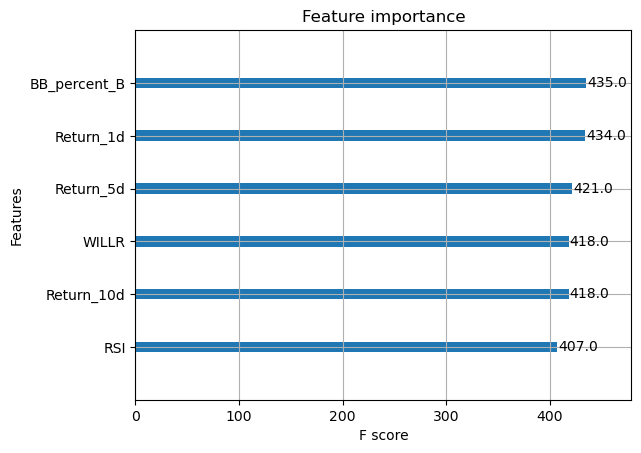

In [25]:
plot_importance(model)

In [24]:
#@title Evaluacion NASDAQ con mejores parametros
symbol = "^IXIC"
data = yf.download(symbol, start="2010-01-01", end="2024-12-31", interval='1d')

# Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Features base y target
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data['Return_1d'] = data['Close'].pct_change()
data['Return_5d'] = data['Close'].pct_change(periods=5)
data['Return_7d'] = data['Close'].pct_change(periods=7)
data['Return_10d'] = data['Close'].pct_change(periods=10)
data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
if 'Volume' in data.columns:
    data.drop(columns=['Volume'], inplace=True)

default_nasdaq_config = {
    'alpha': 310,
    'rsi_window': 21,
    'willr_window': 14,
    'bb_window': 5,
    'features_subset': ['Return_1d', 'Return_5d', 'Return_10d', 'RSI', 'WILLR', 'BB_percent_B']
}

cfg = best_nasdaq_params if 'best_nasdaq_params' in globals() and best_nasdaq_params else default_nasdaq_config

# Definir helper si no existe en el estado del kernel
if 'generate_features_nasdaq' not in globals():
    def generate_features_nasdaq(data, rsi_window, willr_window, bb_window, alpha, selected_features):
        df = data.copy()
        df['RSI'] = ta.momentum.RSIIndicator(close=df['Close'], window=rsi_window).rsi()
        df['WILLR'] = ta.momentum.WilliamsRIndicator(
            high=df['High'], low=df['Low'], close=df['Close'], lbp=willr_window
        ).williams_r()
        bb = ta.volatility.BollingerBands(close=df['Close'], window=bb_window, window_dev=2)
        df['BB_percent_B'] = bb.bollinger_pband()
        change = abs(df['Return_1d'])
        df['Weight'] = 1 / (1 + alpha * change)
        df.dropna(inplace=True)
        X = df[selected_features]
        y = df['Target']
        w = df['Weight']
        return X, y, w

X, y, w = generate_features_nasdaq(
    data,
    rsi_window=cfg['rsi_window'],
    willr_window=cfg['willr_window'],
    bb_window=cfg['bb_window'],
    alpha=cfg['alpha'],
    selected_features=cfg['features_subset']
 )

# Split temporal train/valid/test
n = len(X)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]
w_train = w.iloc[:train_end]
w_val = w.iloc[train_end:val_end]

# Entrenar final en train+val y evaluar en test
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])
w_train_final = pd.concat([w_train, w_val])

model_nasdaq = XGBClassifier(eval_metric='logloss', random_state=42)
model_nasdaq.fit(X_train_final, y_train_final, sample_weight=w_train_final)

y_pred = model_nasdaq.predict(X_test)
model = model_nasdaq  # Para que celdas de grafica/importancia sigan funcionando

print('Configuracion NASDAQ usada:', cfg)
print('Accuracy NASDAQ (test):', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[*********************100%***********************]  1 of 1 completed


Configuracion NASDAQ usada: {'alpha': 310, 'bb_window': 5, 'features_subset': ['Return_1d', 'Return_5d', 'Return_10d', 'RSI', 'WILLR', 'BB_percent_B'], 'rsi_window': 21, 'willr_window': 14}
Accuracy NASDAQ (test): 0.5046604527296937
              precision    recall  f1-score   support

           0       0.46      0.35      0.40       353
           1       0.53      0.64      0.58       398

    accuracy                           0.50       751
   macro avg       0.50      0.50      0.49       751
weighted avg       0.50      0.50      0.49       751



## USD COP

### Experimentos dedicados en COPUSD
Aqui el modelo se entrena y evalua directamente en COPUSD (sin transferencia).

Comparar este bloque con la transferencia EURUSD -> COPUSD ayuda a medir cuanto aporta entrenar en el activo objetivo.

In [26]:
#@title Entrenamiento modelo predicción a 1 dia
#Datos
symbol = 'COPUSD=X'
data = yf.download(symbol, start="2010-01-01", end="2024-12-31", interval='1d')

#Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


#Target: 1 si sube 0 si baja
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Features
data['Return_1d'] = data['Close'].pct_change()
data['Return_5d'] = data['Close'].pct_change(periods=5)
data['Return_7d'] = data['Close'].pct_change(periods=7)
data['Return_10d'] = data['Close'].pct_change(periods=10)
data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
data['STD_5'] = data['Close'].rolling(5).std()
data['STD_10'] = data['Close'].rolling(10).std()
data['Momentum'] = data['Close'] - data['Close'].shift(5)
data.drop(columns=['Volume'], inplace=True)

#otros features buenos para XGBoost
# RSI (Relative Strength Index)
data['RSI_14'] = ta.momentum.RSIIndicator(close=data['Close'], window=14).rsi()
# MACD
macd = ta.trend.MACD(data['Close'])
data['MACD'] = macd.macd_diff()
# Williams %R
data['WILLR'] = ta.momentum.WilliamsRIndicator(high=data['High'], low=data['Low'], close=data['Close'], lbp=14).williams_r()

#Peso
change = abs(data['Return_7d'])
alpha = 110 # Ajustar este valor según la sensibilidad deseada
data['Weight'] = 1 / (1 + alpha * change)

#Para quitar el peso
#data['Weight'] = np.ones(len(data))

# Features y target
data.dropna(inplace=True)
features = ['Return_1d','Return_5d','Return_7d', 'Return_10d', 'MA_5', 'MA_10',
            'STD_5', 'STD_10', 'Momentum','RSI_14', 'MACD', 'WILLR']
X = data[features]
y = data['Target']
w = data['Weight']

#train/test
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, shuffle=False, test_size=0.2)

# Entrenar modelo
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train, sample_weight=w_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[*********************100%***********************]  1 of 1 completed


Accuracy: 0.5834411384217335
              precision    recall  f1-score   support

           0       0.61      0.36      0.46       370
           1       0.57      0.78      0.66       403

    accuracy                           0.58       773
   macro avg       0.59      0.57      0.56       773
weighted avg       0.59      0.58      0.56       773



**El mejor resultado se obtuvo con alpha = 110**

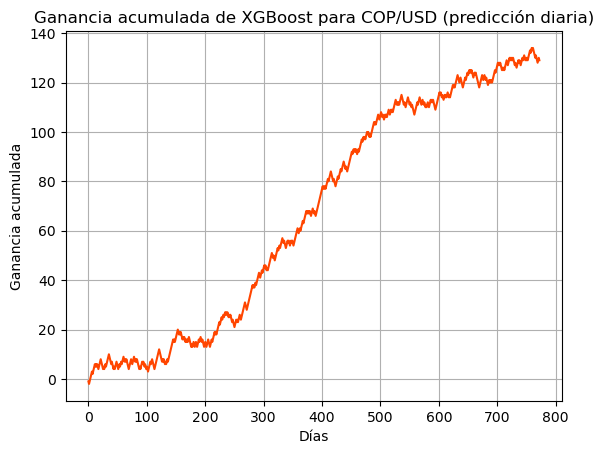

In [27]:
#@title Ganancia acumulada: Gana +1 si acerta, -1 si falla
sim_returns = np.where(y_pred == y_test.values, 1, -1)
cumulative_return = np.cumsum(sim_returns)

plt.plot(cumulative_return,color='orangered')
plt.title("Ganancia acumulada de XGBoost para COP/USD (predicción diaria)")
plt.xlabel("Días")
plt.ylabel("Ganancia acumulada")
plt.grid()
plt.show()

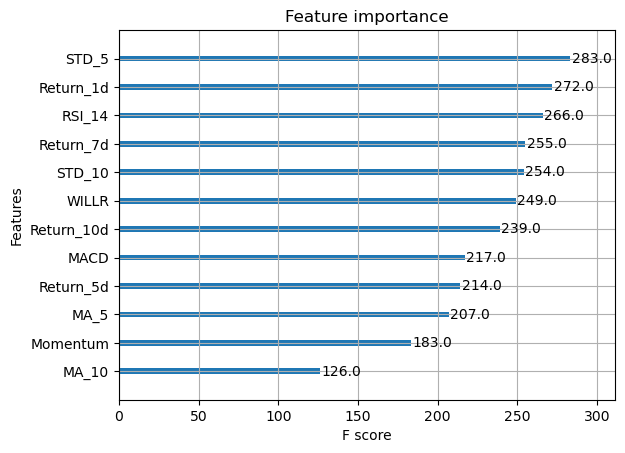

In [28]:
plot_importance(model)
plt.show()

In [29]:
#@title Grafica
data_test = data.iloc[-len(y_test):].copy()
data_test['Pred'] = y_pred

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data_test.index,
    y=data_test['Close'],
    mode='lines',
    name='Precio COP/USD',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=data_test.index[data_test['Pred'] == 1],
    y=data_test['Close'][data_test['Pred'] == 1],
    mode='markers',
    name='Predicción: Sube',
    marker=dict(color='green', symbol='triangle-up', size=10)
))

fig.add_trace(go.Scatter(
    x=data_test.index[data_test['Pred'] == 0],
    y=data_test['Close'][data_test['Pred'] == 0],
    mode='markers',
    name='Predicción: Baja',
    marker=dict(color='red', symbol='triangle-down', size=10)
))

fig.update_layout(
    title='COP/USD y Predicciones de XGBoost',
    xaxis_title='Fecha',
    yaxis_title='Precio de cierre',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

### 1 semana

### Horizonte semanal
En este bloque el target cambia a 7 dias hacia adelante.

La interpretacion de la senal es menos sensible al ruido diario, pero reacciona mas lento a cambios de tendencia.

In [30]:
#@title Entrenamiento modelo predicción a 1 semana
#Datos
symbol = 'EURUSD=X'
data = yf.download(symbol, start="2010-01-01", end="2024-12-31", interval='1d')

#Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


#Target
data['Target'] = (data['Close'].shift(-7) > data['Close']).astype(int)

# Features
data['Return_1d'] = data['Close'].pct_change()
#data['Return_5d'] = data['Close'].pct_change(periods=5)
data['Return_7d'] = data['Close'].pct_change(periods=7)
data['Return_10d'] = data['Close'].pct_change(periods=10)

data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()

data['STD_5'] = data['Close'].rolling(5).std()
data['STD_10'] = data['Close'].rolling(10).std()

data['Momentum'] = data['Close'] - data['Close'].shift(7)
data.drop(columns=['Volume'], inplace=True)

#otros features buenos para XGBoost
# RSI (Relative Strength Index)
data['RSI_14'] = ta.momentum.RSIIndicator(close=data['Close'], window=14).rsi()
# MACD
macd = ta.trend.MACD(data['Close'])
data['MACD'] = macd.macd_diff()
# Williams %R
data['WILLR'] = ta.momentum.WilliamsRIndicator(high=data['High'], low=data['Low'], close=data['Close'], lbp=14).williams_r()

#Peso
change = abs(data['Return_7d'])
alpha = 200 # Ajustar este valor según la sensibilidad deseada
data['Weight'] = 1 / (1 + alpha * change)

#Para quitar el peso
data['Weight'] = np.ones(len(data))

# Features y target
data.dropna(inplace=True)
features = ['Return_1d', 'MA_5', 'MA_10', 'STD_5', 'STD_10', 'RSI_14', 'MACD', 'WILLR','Momentum']
X = data[features]
y = data['Target']
w = data['Weight']

# train/test
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, shuffle=False, test_size=0.2)

#Entrenar modelo
model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate = 0.05, eval_metric='logloss')
model.fit(X_train, y_train, sample_weight=w_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[*********************100%***********************]  1 of 1 completed


Accuracy: 0.5303225806451612
              precision    recall  f1-score   support

           0       0.77      0.18      0.29       417
           1       0.50      0.94      0.65       358

    accuracy                           0.53       775
   macro avg       0.63      0.56      0.47       775
weighted avg       0.64      0.53      0.46       775



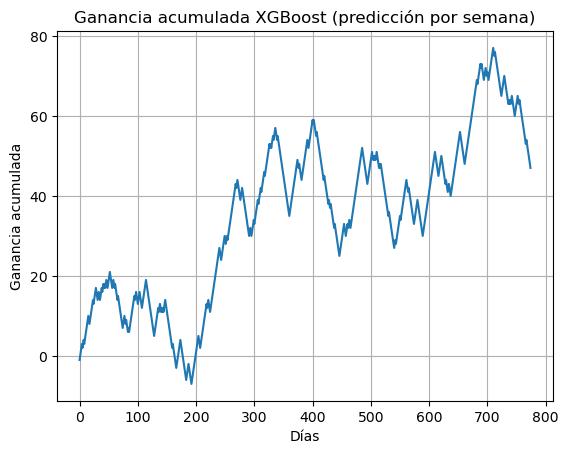

In [31]:
#@title Ganancia acumulada: Gana +1 si acerta, -1 si falla
sim_returns = np.where(y_pred == y_test.values, 1, -1)
cumulative_return = np.cumsum(sim_returns)

plt.plot(cumulative_return)
plt.title("Ganancia acumulada XGBoost (predicción por semana)")
plt.xlabel("Días")
plt.ylabel("Ganancia acumulada")
plt.grid()
plt.show()

<AxesSubplot: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

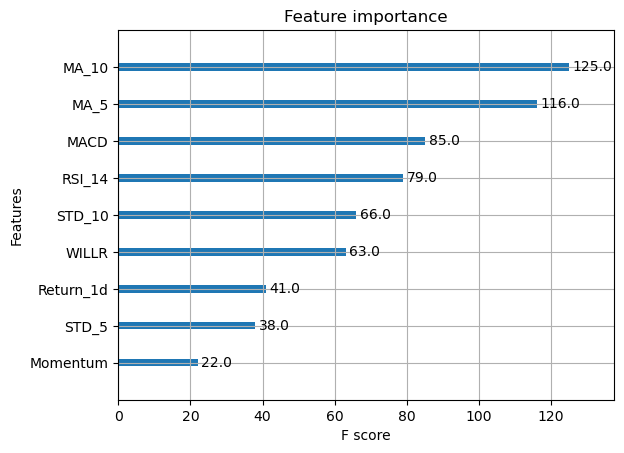

In [32]:
plot_importance(model)

In [33]:
#@title Gráfica
data_test = data.iloc[-len(y_test):].copy()
data_test['Pred'] = y_pred

# Predicciones cada 7 días
every_7 = data_test.iloc[::7].copy()
every_7['Pred'] = y_pred[::7]

fig = go.Figure()

#Precios vs Fecha
fig.add_trace(go.Scatter(
    x=data_test.index,
    y=data_test['Close'],
    mode='lines',
    name='Precio EUR/USD',
    line=dict(color='blue')
))

#Flechas verdes: predicción de subida cada 7 días
fig.add_trace(go.Scatter(
    x=every_7.index[every_7['Pred'] == 1],
    y=every_7['Close'][every_7['Pred'] == 1],
    mode='markers',
    name='Predicción: Sube en 7 días',
    marker=dict(color='green', symbol='triangle-up', size=12)
))

#Flechas rojas: predicción de bajada cada 7 días
fig.add_trace(go.Scatter(
    x=every_7.index[every_7['Pred'] == 0],
    y=every_7['Close'][every_7['Pred'] == 0],
    mode='markers',
    name='Predicción: Baja en 7 días',
    marker=dict(color='red', symbol='triangle-down', size=12)
))

fig.update_layout(
    title='Predicciones de XGBoost cada 7 días',
    xaxis_title='Fecha',
    yaxis_title='Precio EUR/USD',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()


### 1 Mes

### Horizonte mensual
Aqui la etiqueta se define a 30 dias, enfocando el modelo en dinamicas de mediano plazo.

Es util para comparar el trade-off entre estabilidad y capacidad de reaccion frente a horizontes cortos.

In [34]:
#@title Entrenamiento modelo predicción a 1 mes
#Datos
symbol = 'EURUSD=X'
data = yf.download(symbol, start="2010-01-01", end="2024-12-31", interval='1d')

#Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


#Target: 1 si sube 0 si baja
data['Target'] = (data['Close'].shift(-30) > data['Close']).astype(int)

# Features
data['Return_1d'] = data['Close'].pct_change()
data['Return_7d'] = data['Close'].pct_change(periods=7)
data['Return_10d'] = data['Close'].pct_change(periods=10)
data['Return_30d'] = data['Close'].pct_change(periods=30)

data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
data['MA_30'] = data['Close'].rolling(30).mean()

data['STD_5'] = data['Close'].rolling(5).std()
data['STD_10'] = data['Close'].rolling(10).std()
data['STD_30'] = data['Close'].rolling(30).std()

data['Momentum'] = data['Close'] - data['Close'].shift(30)
data.drop(columns=['Volume'], inplace=True)

#otros features buenos para XGBoost
# RSI (Relative Strength Index)
data['RSI_14'] = ta.momentum.RSIIndicator(close=data['Close'], window=14).rsi()
data['RSI_30'] = ta.momentum.RSIIndicator(close=data['Close'], window=30).rsi()
# MACD
macd = ta.trend.MACD(data['Close'])
data['MACD'] = macd.macd_diff()
# Williams %R
data['WILLR_43'] = ta.momentum.WilliamsRIndicator(high=data['High'],
                                               low=data['Low'],
                                               close=data['Close'],
                                               lbp=43).williams_r()
data['WILLR_14'] = ta.momentum.WilliamsRIndicator(high=data['High'],
                                               low=data['Low'],
                                               close=data['Close'],
                                               lbp=14).williams_r()

#Peso
change = abs(data['Return_30d'])
alpha = 190 # Ajustar este valor según la sensibilidad deseada
data['Weight'] = 1 / (1 + alpha * change)

#Para quitar el peso
#data['Weight'] = np.ones(len(data))

# Features y target
data.dropna(inplace=True)
features = ['Return_1d','Return_7d', 'Return_10d', 'MA_5', 'MA_10',
            'STD_5', 'STD_10', 'Momentum','RSI_14', 'MACD', 'WILLR_14','WILLR_43',
            'Return_30d', 'RSI_30', 'MA_30','STD_30']
X = data[features]
y = data['Target']
w = data['Weight']

#train/test
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w,
                                                                     shuffle=False,
                                                                     test_size=0.2)

# Entrenar modelo
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train, sample_weight=w_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[*********************100%***********************]  1 of 1 completed


Accuracy: 0.5200517464424321
              precision    recall  f1-score   support

           0       0.84      0.22      0.35       451
           1       0.46      0.94      0.62       322

    accuracy                           0.52       773
   macro avg       0.65      0.58      0.48       773
weighted avg       0.68      0.52      0.46       773



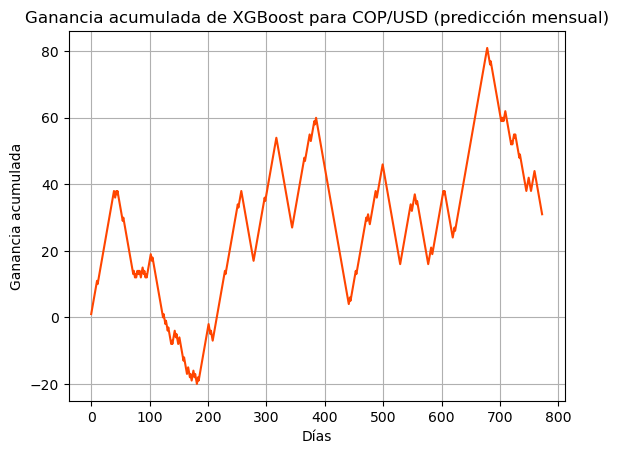

In [35]:
#@title Ganancia acumulada: Gana +1 si acerta, -1 si falla
sim_returns = np.where(y_pred == y_test.values, 1, -1)
cumulative_return = np.cumsum(sim_returns)

plt.plot(cumulative_return,color='orangered')
plt.title("Ganancia acumulada de XGBoost para COP/USD (predicción mensual)")
plt.xlabel("Días")
plt.ylabel("Ganancia acumulada")
plt.grid()
plt.show()

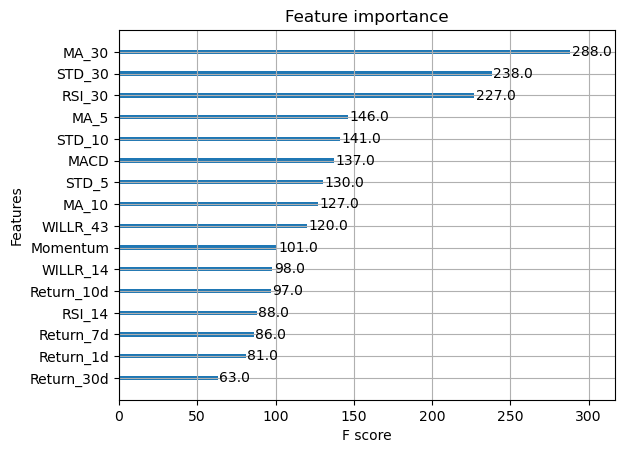

In [36]:
#grafica de features
plot_importance(model)
plt.show()

In [37]:
#@title Gráfica
data_test = data.iloc[-len(y_test):].copy()
data_test['Pred'] = y_pred

# Predicciones cada 7 días
every_30 = data_test.iloc[::30].copy()
every_30['Pred'] = y_pred[::30]

fig = go.Figure()

#Precios vs Fecha
fig.add_trace(go.Scatter(
    x=data_test.index,
    y=data_test['Close'],
    mode='lines',
    name='Precio EUR/USD',
    line=dict(color='blue')
))

#Flechas verdes: predicción de subida cada 30 días
fig.add_trace(go.Scatter(
    x=every_30.index[every_30['Pred'] == 1],
    y=every_30['Close'][every_30['Pred'] == 1],
    mode='markers',
    name='Predicción: Sube en 30 días',
    marker=dict(color='green', symbol='triangle-up', size=12)
))

#Flechas rojas: predicción de bajada cada 30 días
fig.add_trace(go.Scatter(
    x=every_30.index[every_30['Pred'] == 0],
    y=every_30['Close'][every_30['Pred'] == 0],
    mode='markers',
    name='Predicción: Baja en 30 días',
    marker=dict(color='red', symbol='triangle-down', size=12)
))

fig.update_layout(
    title='Predicciones de XGBoost cada 30 días',
    xaxis_title='Fecha',
    yaxis_title='Precio EUR/USD',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

In [38]:
#@title Encontrar el mejor alpha

best_alpha = 0
best_acc = 0
alpha_values = range(1, 1000, 10) # Rango de valores para alpha

# Copiar los datos originales para no modificarlos en el bucle
data_copy = data.copy()

for alpha in alpha_values:
    # Calcular peso con el alpha actual
    change = abs(data_copy['Return_30d'])
    data_copy['Weight'] = 1 / (1 + alpha * change)

    # Features y target con el peso actualizado
    data_alpha = data_copy.dropna()
    X_alpha = data_alpha[features]
    y_alpha = data_alpha['Target']
    w_alpha = data_alpha['Weight']

    # train/test con los datos actualizados
    X_train_alpha, X_test_alpha, y_train_alpha, y_test_alpha, w_train_alpha, w_test_alpha = train_test_split(X_alpha, y_alpha, w_alpha, shuffle=False, test_size=0.2)

    # Entrenar modelo con el peso actualizado
    model_alpha = XGBClassifier(eval_metric='logloss')
    model_alpha.fit(X_train_alpha, y_train_alpha, sample_weight=w_train_alpha)

    # Predicción
    y_pred_alpha = model_alpha.predict(X_test_alpha)

    # Evaluación con F1-score
    acc = accuracy_score(y_test_alpha, y_pred_alpha)

    # Actualizar si es mejor
    if acc > best_acc:
        best_acc = acc
        best_alpha = alpha

print(f"El mejor alpha encontrado es: {best_alpha} con un F1-score de: {best_acc}")

El mejor alpha encontrado es: 701 con un F1-score de: 0.5226390685640362


In [39]:
#@title Entrenamiento modelo predicción a 1 mes
#Datos
symbol = 'EURUSD=X'
data = yf.download(symbol, start="2010-01-01", end="2024-12-31", interval='1d')

#Para quitar el multiindex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


#Target: 1 si sube 0 si baja
data['Target'] = (data['Close'].shift(-30) > data['Close']).astype(int)

# Features
data['Return_30d'] = data['Close'].pct_change(periods=30)
data['Return_35d'] = data['Close'].pct_change(periods=35)
data['Return_40d'] = data['Close'].pct_change(periods=40)

data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
data['MA_30'] = data['Close'].rolling(30).mean()

data['STD_5'] = data['Close'].rolling(5).std()
data['STD_10'] = data['Close'].rolling(10).std()
data['STD_30'] = data['Close'].rolling(30).std()

data['Momentum'] = data['Close'] - data['Close'].shift(35)
data.drop(columns=['Volume'], inplace=True)

#otros features buenos para XGBoost
# RSI (Relative Strength Index)
data['RSI_30'] = ta.momentum.RSIIndicator(close=data['Close'], window=30).rsi()
# MACD
macd = ta.trend.MACD(data['Close'])
data['MACD'] = macd.macd_diff()

#Peso
change = abs(data['Return_30d'])
alpha = 290 # Ajustar este valor según la sensibilidad deseada
data['Weight'] = 1 / (1 + alpha * change)

#Para quitar el peso
#data['Weight'] = np.ones(len(data))

# Features y target
data.dropna(inplace=True)
features = ['MA_5', 'MA_10', 'STD_5', 'STD_10', 'Momentum','MACD',
            'RSI_30', 'MA_30','STD_30',
            'Return_35d','Return_40d']
X = data[features]
y = data['Target']
w = data['Weight']

#train/test
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w,
                                                                     shuffle=False,
                                                                     test_size=0.2)

# Entrenar modelo
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train, sample_weight=w_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[*********************100%***********************]  1 of 1 completed


Accuracy: 0.5142118863049095
              precision    recall  f1-score   support

           0       0.81      0.22      0.35       452
           1       0.46      0.93      0.61       322

    accuracy                           0.51       774
   macro avg       0.63      0.57      0.48       774
weighted avg       0.66      0.51      0.46       774



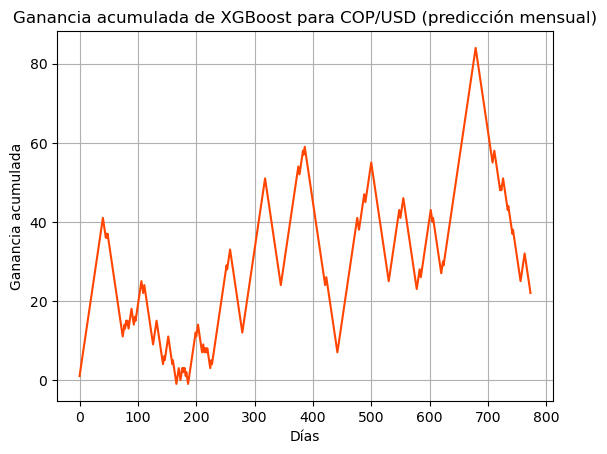

In [40]:
#@title Ganancia acumulada: Gana +1 si acerta, -1 si falla
sim_returns = np.where(y_pred == y_test.values, 1, -1)
cumulative_return = np.cumsum(sim_returns)

plt.plot(cumulative_return,color='orangered')
plt.title("Ganancia acumulada de XGBoost para COP/USD (predicción mensual)")
plt.xlabel("Días")
plt.ylabel("Ganancia acumulada")
plt.grid()
plt.show()

In [41]:
#@title Gráfica
data_test = data.iloc[-len(y_test):].copy()
data_test['Pred'] = y_pred

# Predicciones cada 7 días
every_30 = data_test.iloc[::30].copy()
every_30['Pred'] = y_pred[::30]

fig = go.Figure()

#Precios vs Fecha
fig.add_trace(go.Scatter(
    x=data_test.index,
    y=data_test['Close'],
    mode='lines',
    name='Precio EUR/USD',
    line=dict(color='blue')
))

#Flechas verdes: predicción de subida cada 30 días
fig.add_trace(go.Scatter(
    x=every_30.index[every_30['Pred'] == 1],
    y=every_30['Close'][every_30['Pred'] == 1],
    mode='markers',
    name='Predicción: Sube en 30 días',
    marker=dict(color='green', symbol='triangle-up', size=12)
))

#Flechas rojas: predicción de bajada cada 30 días
fig.add_trace(go.Scatter(
    x=every_30.index[every_30['Pred'] == 0],
    y=every_30['Close'][every_30['Pred'] == 0],
    mode='markers',
    name='Predicción: Baja en 30 días',
    marker=dict(color='red', symbol='triangle-down', size=12)
))

fig.update_layout(
    title='Predicciones de XGBoost cada 30 días',
    xaxis_title='Fecha',
    yaxis_title='Precio EUR/USD',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()